In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family'] = 'Malgun Gothic'
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
import xgboost as xgb

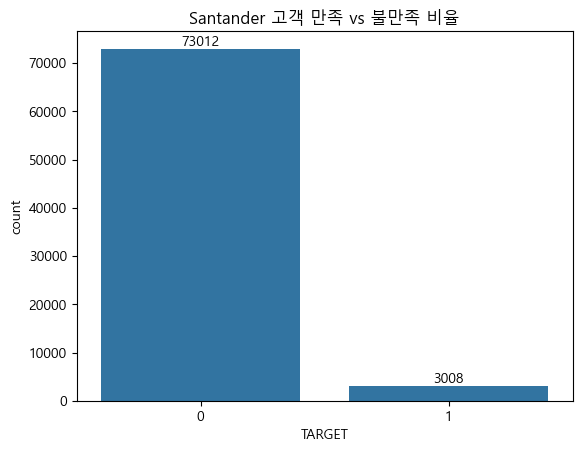

In [2]:
# 고객 만족 vs 불만족 비율 시각화 

df = pd.read_csv('../data/train.csv')

ax = sns.countplot(x="TARGET", data=df)
plt.title("Santander 고객 만족 vs 불만족 비율")

# 각 막대 위에 수치 표시
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2.,  # 막대 중앙
        height,                          # 막대 높이
        f'{int(height)}',                # 표시할 수치
        ha="center", va="bottom"         # 정렬
    )

plt.show()

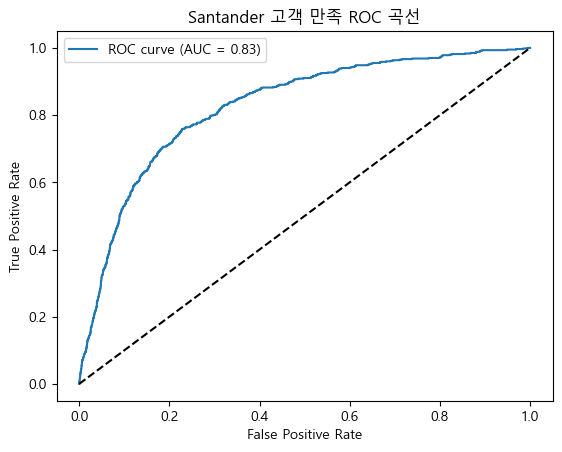

In [3]:
# ROC 곡선

# 모델의 분류 성능 시각적으로 평가
'''
    - X축 (False Positive Rate, FPR): 실제로는 만족 고객인데 불만족으로 잘못 분류한 비율
    - Y축 (True Positive Rate, TPR): 실제 불만족 고객을 올바르게 분류한 비율
    - ROC 곡선: 모델의 임계값을 변화시키면서 FPR과 TPR을 그린 곡선
    - 대각선(랜덤 분류기): 성능이 없는 모델은 (0,0)에서 (1,1)로 이어지는 대각선에 가까움
    - AUC (Area Under Curve): ROC 곡선 아래 면적
        - 1.0에 가까울수록 → 완벽한 분류
        - 0.5에 가까울수록 → 랜덤 추측 수준
'''

X = df.drop("TARGET", axis=1)
y = df["TARGET"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

model = xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss")
model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Santander 고객 만족 ROC 곡선")
plt.legend()
plt.show()

In [4]:
df.describe()

,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
count,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,...,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,7.602000e+04,76020.000000
mean,75964.050723,-1523.199277,33.212865,86.208265,72.363067,119.529632,3.559130,6.472698,0.412946,0.567352,...,7.935824,1.365146,12.215580,8.784074,31.505324,1.858575,76.026165,56.614351,1.172358e+05,0.039569
std,43781.947379,39033.462364,12.956486,1614.757313,339.315831,546.266294,93.155749,153.737066,30.604864,36.513513,...,455.887218,113.959637,783.207399,538.439211,2013.125393,147.786584,4040.337842,2852.579397,1.826646e+05,0.194945
min,1.000000,-999999.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.163750e+03,0.000000
25%,38104.750000,2.000000,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.787061e+04,0.000000
50%,76043.000000,2.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.064092e+05,0.000000
75%,113748.750000,2.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.187563e+05,0.000000
max,151838.000000,238.000000,105.000000,210000.000000,12888.030000,21024.810000,8237.820000,11073.570000,6600.000000,6600.000000,...,50003.880000,20385.720000,138831.630000,91778.730000,438329.220000,24650.010000,681462.900000,397884.300000,2.203474e+07,1.000000


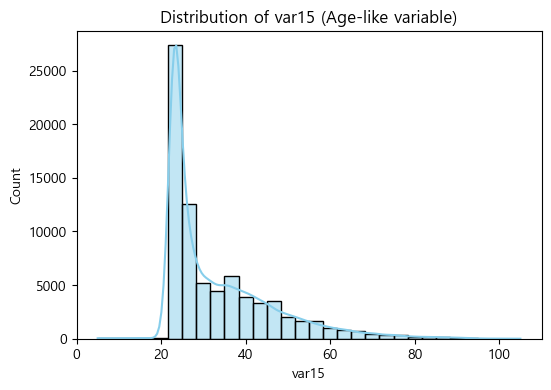

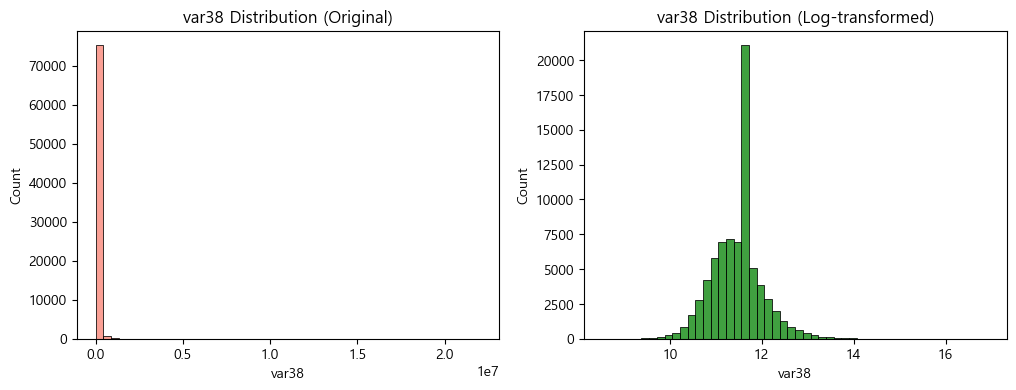

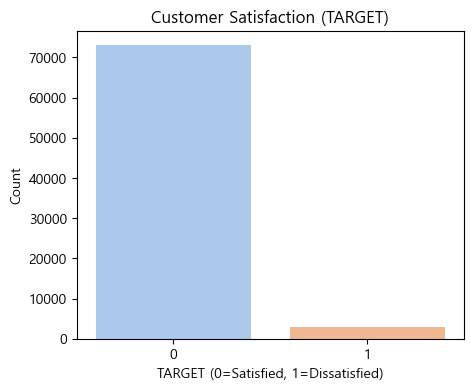

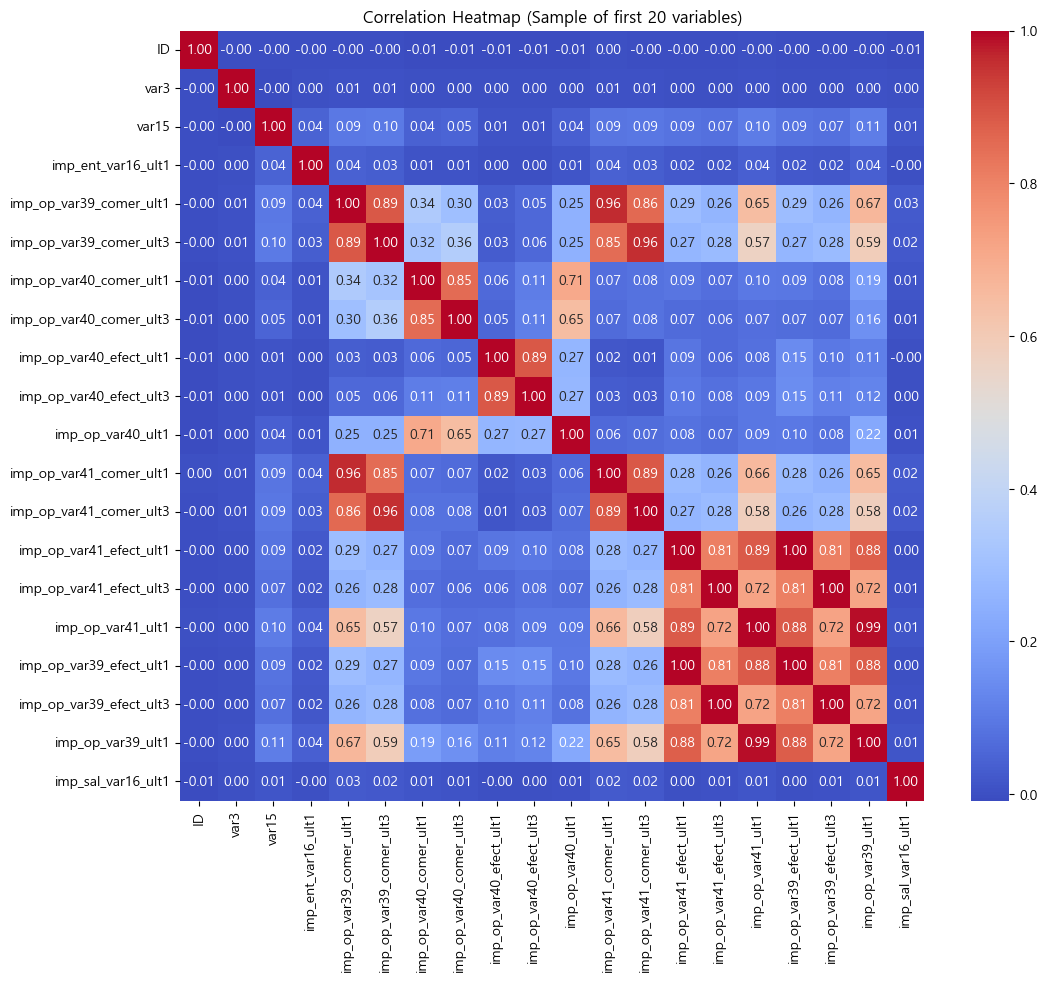

In [6]:
# 1. var15 (나이 추정) 히스토그램
plt.figure(figsize=(6,4))
sns.histplot(df['var15'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of var15 (Age-like variable)")
plt.xlabel("var15")
plt.ylabel("Count")
plt.show()

# 2. var38 (자산 규모 추정) 히스토그램 (로그 변환 전후 비교)
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(df['var38'], bins=50, ax=axes[0], color='salmon')
axes[0].set_title("var38 Distribution (Original)")

sns.histplot(np.log1p(df['var38']), bins=50, ax=axes[1], color='green')
axes[1].set_title("var38 Distribution (Log-transformed)")

plt.show()

# 3. TARGET (만족/불만족) 막대 그래프
plt.figure(figsize=(5,4))
sns.countplot(x='TARGET', data=df, palette='pastel')
plt.title("Customer Satisfaction (TARGET)")
plt.xlabel("TARGET (0=Satisfied, 1=Dissatisfied)")
plt.ylabel("Count")
plt.show()

# 4. 상관관계 Heatmap (상위 변수만 샘플링)
# 전체 370개 변수는 너무 많으므로, 예시로 앞 20개 변수만 사용
corr = df.iloc[:, :20].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap (Sample of first 20 variables)")
plt.show()

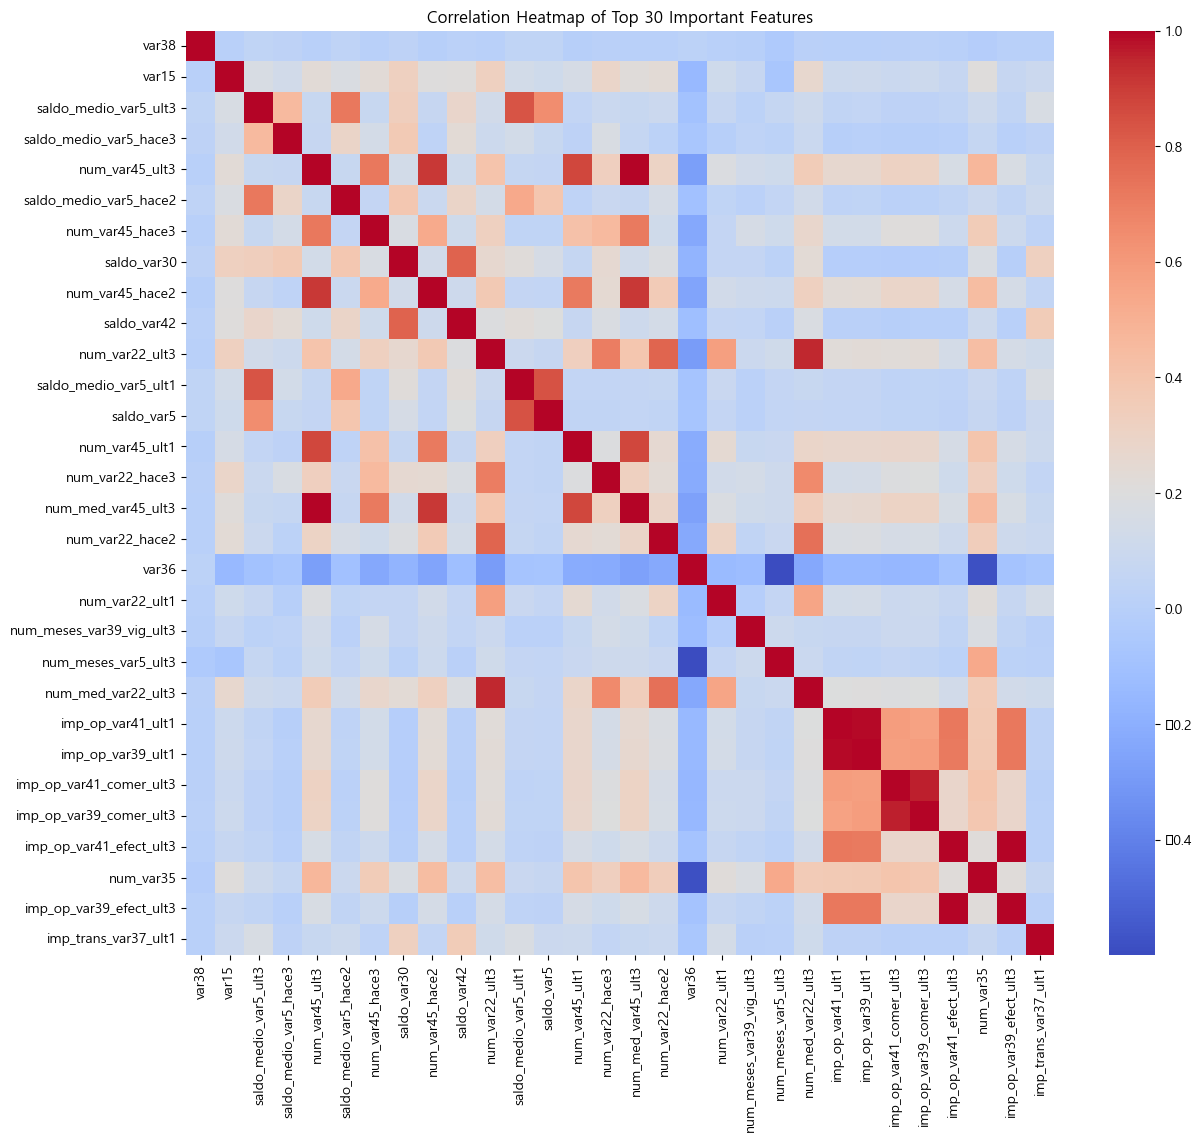

In [8]:
from sklearn.ensemble import RandomForestClassifier

# 피처와 타깃 분리
X = df.drop(columns=['TARGET', 'ID'])
y = df['TARGET']

# RandomForest로 변수 중요도 계산
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X, y)

# 변수 중요도 추출
importances = pd.Series(model.feature_importances_, index=X.columns)

# 상위 30개 변수 선택
top30_features = importances.sort_values(ascending=False).head(30).index

# 상위 30개 변수의 상관관계 계산
corr_top30 = df[top30_features].corr()

# Heatmap 시각화
plt.figure(figsize=(14,12))
sns.heatmap(corr_top30, annot=False, cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap of Top 30 Important Features")
plt.show()